# Klasifikasi Risiko Gagal Bayar Nasabah Menggunakan Algoritma Random Forest
### Pendekatan Penanganan Imbalanced Data untuk Mendukung Kebijakan Manajemen Risiko Kredit

**Notebook Eksperimen** — disusun mengikuti struktur BAB 3 (Analisis Dataset), BAB 4 (Perancangan Pipeline), dan BAB 5 (Strategi Pemodelan & Eksperimen) pada proposal penelitian.

Dataset: `Default_Fin.csv` (10.000 baris, 4 fitur input + 1 label `Defaulted?`)


In [20]:
# Import library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

np.random.seed(RANDOM_STATE)


## BAB 3 — Analisis Dataset dan Representasi

### 3.1–3.2 Memuat Data & Struktur Data

In [21]:
df = pd.read_csv("Default_Fin.csv")

print("Shape:", df.shape)
df.head()   
df_clean = df.copy()

Shape: (10000, 5)


In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          10000 non-null  int64  
 1   Employed       10000 non-null  int64  
 2   Bank Balance   10000 non-null  float64
 3   Annual Salary  10000 non-null  float64
 4   Defaulted?     10000 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [23]:
# Cek missing values
print("Missing values per kolom:")
print(df.isnull().sum())

# Cek duplikat
print("\nJumlah baris duplikat:", df.duplicated().sum())


Missing values per kolom:
Index            0
Employed         0
Bank Balance     0
Annual Salary    0
Defaulted?       0
dtype: int64

Jumlah baris duplikat: 0


In [24]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Index,"10,000.0000","5,000.5000","2,886.8957",1.0000,"2,500.7500","5,000.5000","7,500.2500","10,000.0000"
Employed,"10,000.0000",0.7056,0.4558,0.0000,0.0000,1.0000,1.0000,1.0000
Bank Balance,"10,000.0000","10,024.4985","5,804.5795",0.0000,"5,780.7900","9,883.6200","13,995.6600","31,851.8400"
Annual Salary,"10,000.0000","402,203.7822","160,039.6750","9,263.6400","256,085.5200","414,631.7400","525,692.7600","882,650.7600"
Defaulted?,"10,000.0000",0.0333,0.1794,0.0000,0.0000,0.0000,0.0000,1.0000


### 3.3 Analisis Ketimpangan Kelas (Class Imbalance)

Ini adalah tantangan utama dari penelitian ini: label `Defaulted?` sangat tidak seimbang.

Distribusi kelas:
Defaulted?
0    9667
1     333
Name: count, dtype: int64

Persentase:
Defaulted?
0   96.6700
1    3.3300
Name: proportion, dtype: float64

Rasio ketimpangan (mayoritas:minoritas) = 29.0 : 1


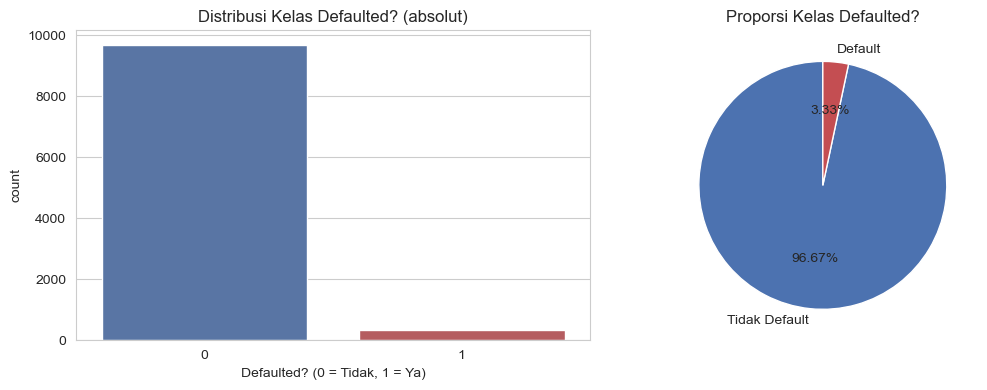

In [25]:
class_counts = df["Defaulted?"].value_counts()
class_pct = df["Defaulted?"].value_counts(normalize=True) * 100
imbalance_ratio = class_counts[0] / class_counts[1]

print("Distribusi kelas:")
print(class_counts)
print("\nPersentase:")
print(class_pct.round(2))
print(f"\nRasio ketimpangan (mayoritas:minoritas) = {imbalance_ratio:.1f} : 1")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="Defaulted?", hue="Defaulted?", data=df, ax=ax[0], palette=["#4C72B0", "#C44E52"], legend=False)
ax[0].set_title("Distribusi Kelas Defaulted? (absolut)")
ax[0].set_xlabel("Defaulted? (0 = Tidak, 1 = Ya)")

ax[1].pie(class_counts, labels=["Tidak Default", "Default"], autopct="%1.2f%%",
          colors=["#4C72B0", "#C44E52"], startangle=90)
ax[1].set_title("Proporsi Kelas Defaulted?")
plt.tight_layout()
plt.show()


### 3.4 Analisis Karakteristik Data — Distribusi Fitur terhadap Target

Melihat bagaimana `Bank Balance`, `Annual Salary`, dan `Employed` berbeda antara nasabah default dan tidak default.

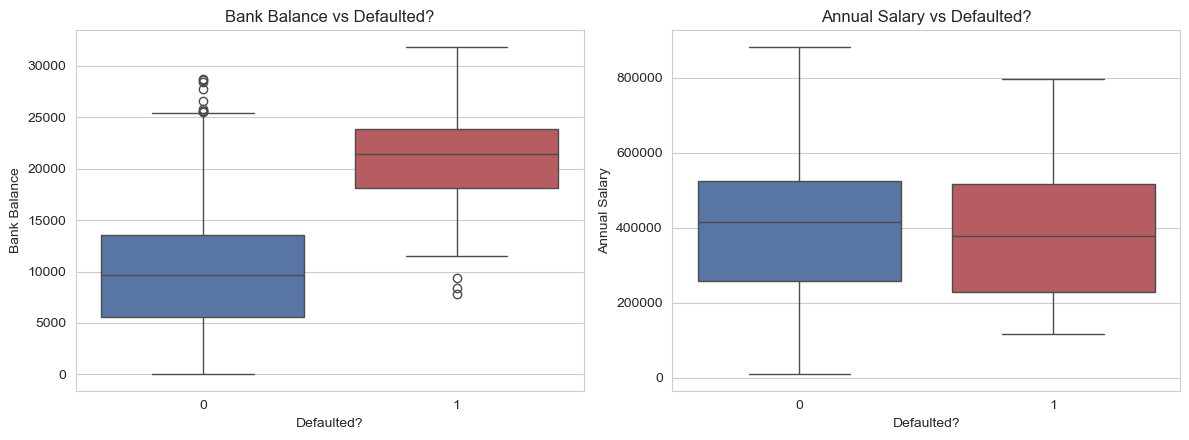

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i, col in enumerate(["Bank Balance", "Annual Salary"]):
    sns.boxplot(x="Defaulted?", y=col, hue="Defaulted?", data=df, ax=axes[i], palette=["#4C72B0", "#C44E52"], legend=False)
    axes[i].set_title(f"{col} vs Defaulted?")
plt.tight_layout()
plt.show()


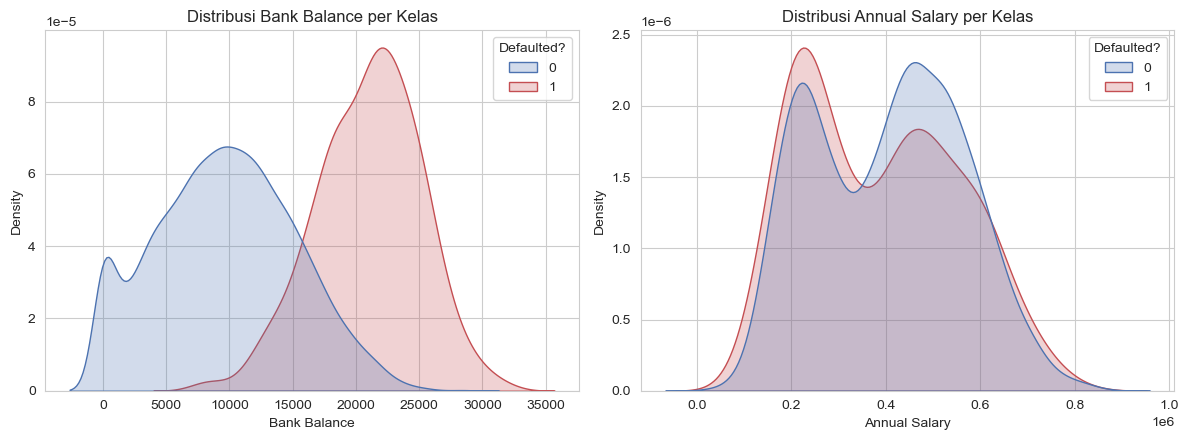

Defaulted?,0,1
Employed,,
0,0.9569,0.0431
1,0.9708,0.0292


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i, col in enumerate(["Bank Balance", "Annual Salary"]):
    sns.kdeplot(data=df, x=col, hue="Defaulted?", fill=True, common_norm=False,
                palette=["#4C72B0", "#C44E52"], ax=axes[i])
    axes[i].set_title(f"Distribusi {col} per Kelas")
plt.tight_layout()
plt.show()

# Employed vs Defaulted? (cross-tab)
pd.crosstab(df["Employed"], df["Defaulted?"], normalize="index").round(4)


### 3.4 (lanjutan) Visualisasi Interaktif dengan Plotly

In [28]:
import plotly.express as px

fig = px.histogram(
    df_clean, x="Bank Balance", color="Defaulted?",
    marginal="box", barmode="overlay", opacity=0.6,
    color_discrete_sequence=["#4C72B0", "#C44E52"],
    title="Distribusi Bank Balance per Status Default (Interaktif)"
)
fig.update_layout(bargap=0.05)
fig.show()


In [29]:
# Deteksi outlier dengan metode IQR (untuk evaluasi, bukan otomatis dibuang —
# lihat justifikasi di BAB 3.4 proposal: nasabah bersaldo sangat rendah relevan
# secara bisnis dan bisa jadi sinyal risiko, bukan noise)
def iqr_outlier_report(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outlier = ((series < lower) | (series > upper)).sum()
    print(f"{name}: batas=[{lower:,.2f}, {upper:,.2f}] -> jumlah outlier = {n_outlier} ({n_outlier/len(series)*100:.2f}%)")

iqr_outlier_report(df["Bank Balance"], "Bank Balance")
iqr_outlier_report(df["Annual Salary"], "Annual Salary")


Bank Balance: batas=[-6,541.51, 26,317.96] -> jumlah outlier = 31 (0.31%)
Annual Salary: batas=[-148,325.34, 930,103.62] -> jumlah outlier = 0 (0.00%)


## BAB 4 — Perancangan Pipeline Pembelajaran Mesin

### 4.1 Data Cleaning

In [30]:
df_clean = df.drop(columns=["Index"]).copy()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Shape setelah cleaning:", df_clean.shape)
df_clean.head()


Shape setelah cleaning: (10000, 4)


,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,"8,754.3600","532,339.5600",0
1,0,"9,806.1600","145,273.5600",0
2,1,"12,882.6000","381,205.6800",0
3,1,"6,351.0000","428,453.8800",0
4,1,"9,427.9200","461,562.0000",0


### 3.5 Analisis Multivariat — Correlation Heatmap

Melihat hubungan linear antar fitur numerik dan target, sekaligus mengecek potensi multikolinearitas antar fitur input. Dihitung setelah df_clean tersedia (BAB 4.1) agar konsisten dengan data yang dipakai di seluruh pipeline.

               Employed  Bank Balance  Annual Salary  Defaulted?
Employed         1.0000       -0.2040         0.7540     -0.0350
Bank Balance    -0.2040        1.0000        -0.1520      0.3500
Annual Salary    0.7540       -0.1520         1.0000     -0.0200
Defaulted?      -0.0350        0.3500        -0.0200      1.0000


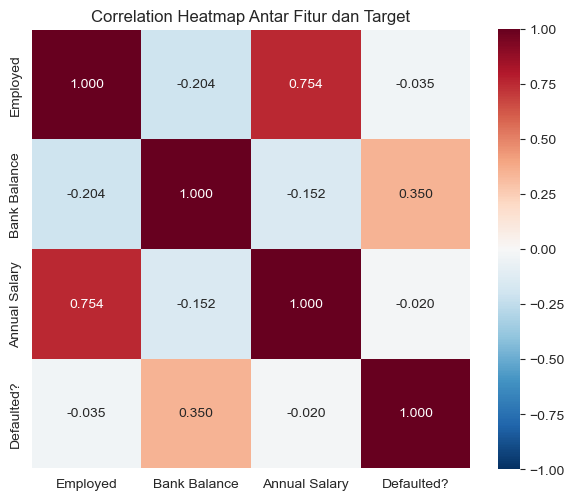

In [31]:
corr = df_clean.corr(numeric_only=True)
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation Heatmap Antar Fitur dan Target")
plt.tight_layout()
plt.show()


### 3.6 Ringkasan 5 Insight Utama

1. Data sangat imbalanced, kelas `Defaulted?` hanya minoritas kecil dari total nasabah (lihat rasio ketimpangan pada cell 3.3), sehingga metrik seperti Accuracy tidak representatif dan perlu dilengkapi F1-Score serta PR-AUC.
2. Nasabah yang tidak bekerja (`Employed` = 0) menunjukkan proporsi default yang lebih tinggi dibanding nasabah yang bekerja, terlihat dari cross-tab pada bagian 3.4.
3. `Bank Balance` yang rendah berasosiasi kuat dengan status default, terlihat dari boxplot dan KDE plot, nasabah default cenderung memiliki saldo bank jauh di bawah nasabah yang tidak default.
4. `Annual Salary` tidak menunjukkan pola pembeda sejelas `Bank Balance`, artinya saldo bank riil lebih informatif dibanding pendapatan tahunan untuk memprediksi risiko gagal bayar.
5. Correlation heatmap pada bagian 3.5 menunjukkan tidak ada multikolinearitas signifikan antar fitur input, sehingga aman digunakan bersama tanpa perlu dihapus salah satunya sebelum masuk ke model.

*Catatan: angka dan pola di atas mengikuti temuan pada cell-cell sebelumnya, cek kembali output aktualnya untuk memastikan kesesuaian sebelum dipakai di laporan.*

### 4.4 Data Splitting Strategy

Stratified split 70:15:15 (train:validation:test) dilakukan **sebelum** feature engineering, scaling, dan penanganan imbalance untuk mencegah *data leakage*. Training set dipakai untuk SMOTE, cross-validation, dan GridSearchCV. Validation set dipakai sebagai pengecekan tambahan sebelum evaluasi akhir. Test set disimpan terpisah dan hanya dipakai satu kali di akhir untuk evaluasi final.

In [32]:
X = df_clean[["Employed", "Bank Balance", "Annual Salary"]].copy()
y = df_clean["Defaulted?"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " | Val shape:", X_val.shape, " | Test shape:", X_test.shape)
print("\nProporsi kelas train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nProporsi kelas val:")
print(y_val.value_counts(normalize=True).round(4))
print("\nProporsi kelas test:")
print(y_test.value_counts(normalize=True).round(4))


Train shape: (7000, 3)  | Val shape: (1500, 3)  | Test shape: (1500, 3)

Proporsi kelas train:
Defaulted?
0   0.9667
1   0.0333
Name: proportion, dtype: float64

Proporsi kelas val:
Defaulted?
0   0.9667
1   0.0333
Name: proportion, dtype: float64

Proporsi kelas test:
Defaulted?
0   0.9667
1   0.0333
Name: proportion, dtype: float64


### 4.2 Feature Engineering

Ditambahkan setelah split, dihitung dari kolom asli (tidak ada leakage karena tidak bergantung pada statistik training set).

In [33]:
def add_engineered_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["Balance_to_Salary_Ratio"] = d["Bank Balance"] / d["Annual Salary"]
    d["Balance_per_Employment"] = d["Bank Balance"] * d["Employed"]
    return d

X_train_fe = add_engineered_features(X_train)
X_val_fe = add_engineered_features(X_val)
X_test_fe = add_engineered_features(X_test)

# Binning Annual Salary -- batas dihitung dari TRAIN saja, lalu diterapkan ke val dan test
bins = pd.qcut(X_train_fe["Annual Salary"], q=3, retbins=True, labels=["rendah", "menengah", "tinggi"])[1]
X_train_fe["Salary_Bin"] = pd.cut(X_train_fe["Annual Salary"], bins=bins, labels=["rendah", "menengah", "tinggi"], include_lowest=True)
X_val_fe["Salary_Bin"] = pd.cut(X_val_fe["Annual Salary"], bins=bins, labels=["rendah", "menengah", "tinggi"], include_lowest=True)
X_test_fe["Salary_Bin"] = pd.cut(X_test_fe["Annual Salary"], bins=bins, labels=["rendah", "menengah", "tinggi"], include_lowest=True)

# One-hot encode Salary_Bin
X_train_fe = pd.get_dummies(X_train_fe, columns=["Salary_Bin"], drop_first=True)
X_val_fe = pd.get_dummies(X_val_fe, columns=["Salary_Bin"], drop_first=True)
X_test_fe = pd.get_dummies(X_test_fe, columns=["Salary_Bin"], drop_first=True)
X_val_fe = X_val_fe.reindex(columns=X_train_fe.columns, fill_value=0)
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

X_train_fe.head()


,Employed,Bank Balance,Annual Salary,Balance_to_Salary_Ratio,Balance_per_Employment,Salary_Bin_menengah,Salary_Bin_tinggi
746,0,"9,829.2000","191,495.2800",0.0513,0.0000,False,False
3688,1,"5,614.3200","519,704.4000",0.0108,"5,614.3200",False,True
8505,1,"3,954.2400","457,807.5600",0.0086,"3,954.2400",True,False
3381,1,"9,391.8000","449,965.0800",0.0209,"9,391.8000",True,False
2868,1,"14,927.1600","456,905.2800",0.0327,"14,927.1600",True,False


### 4.1 (lanjutan) Feature Scaling

`StandardScaler` di-*fit* hanya pada training set, kemudian diterapkan (transform) ke training maupun test set.
Kolom biner (`Employed`, hasil one-hot `Salary_Bin`) tidak di-scale.

In [34]:
numeric_cols = ["Bank Balance", "Annual Salary", "Balance_to_Salary_Ratio", "Balance_per_Employment"]

scaler = StandardScaler()
X_train_scaled = X_train_fe.copy()
X_val_scaled = X_val_fe.copy()
X_test_scaled = X_test_fe.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_fe[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val_fe[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_fe[numeric_cols])

X_train_scaled.head()


,Employed,Bank Balance,Annual Salary,Balance_to_Salary_Ratio,Balance_per_Employment,Salary_Bin_menengah,Salary_Bin_tinggi
746,0,-0.0382,-1.3113,0.5260,-1.0353,False,False
3688,1,-0.7701,0.7370,-0.6159,-0.1460,False,True
8505,1,-1.0583,0.3507,-0.6769,-0.4090,True,False
3381,1,-0.1142,0.3018,-0.3322,0.4524,True,False
2868,1,0.8470,0.3451,0.0003,1.3293,True,False


### 4.3 Penanganan Imbalanced Data

Disiapkan fungsi SMOTE (Chawla et al., 2002). Jika library `imbalanced-learn` tersedia di environment, digunakan implementasi resminya;
jika tidak, digunakan implementasi manual berbasis k-Nearest Neighbors sebagai fallback agar notebook tetap bisa dijalankan tanpa dependensi tambahan.

In [35]:
def manual_smote(X, y, minority_label=1, k=5, random_state=RANDOM_STATE):
    """Implementasi sederhana SMOTE: interpolasi linear antar titik minoritas dan k-NN-nya."""
    rng = np.random.RandomState(random_state)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    X_min = X[y == minority_label]
    n_min = X_min.shape[0]
    n_maj = (y != minority_label).sum()
    n_to_generate = n_maj - n_min
    if n_to_generate <= 0:
        return X, y

    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_min)
    neighbors = nn.kneighbors(X_min, return_distance=False)[:, 1:]

    synthetic = np.zeros((n_to_generate, X.shape[1]))
    for i in range(n_to_generate):
        idx = rng.randint(0, n_min)
        nn_idx = neighbors[idx][rng.randint(0, k)]
        gap = rng.rand()
        synthetic[i] = X_min[idx] + gap * (X_min[nn_idx] - X_min[idx])

    X_res = np.vstack([X, synthetic])
    y_res = np.concatenate([y, np.full(n_to_generate, minority_label)])
    return X_res, y_res


def apply_smote(X, y, random_state=RANDOM_STATE):
    """Coba pakai imblearn.SMOTE, fallback ke manual_smote bila tidak tersedia.
    Selalu mengembalikan DataFrame/Series agar nama kolom fitur tetap konsisten."""
    cols = X.columns if hasattr(X, "columns") else None
    try:
        from imblearn.over_sampling import SMOTE
        sm = SMOTE(random_state=random_state)
        X_res, y_res = sm.fit_resample(X, y)
    except ImportError:
        X_res, y_res = manual_smote(np.asarray(X), np.asarray(y), random_state=random_state)

    if cols is not None:
        X_res = pd.DataFrame(X_res, columns=cols)
    y_res = pd.Series(np.asarray(y_res), name=getattr(y, "name", "target"))
    return X_res, y_res

# Cek hasil SMOTE pada training set
X_smote, y_smote = apply_smote(X_train_scaled, y_train)
print("Sebelum SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("Sesudah SMOTE :", pd.Series(y_smote).value_counts().to_dict())


Sebelum SMOTE: {0: 6767, 1: 233}
Sesudah SMOTE : {0: 6767, 1: 6767}


## BAB 5 — Strategi Pemodelan dan Eksperimen

### 5.1–5.2 Definisi Model & Rancangan Eksperimen

Empat skenario penanganan imbalance dibandingkan untuk dua algoritma (Random Forest sebagai model utama,
Logistic Regression sebagai baseline), dievaluasi dengan **Stratified 5-Fold Cross-Validation** pada training set.
Metrik utama CV: `f1` dan `average_precision` (PR-AUC) — bukan `accuracy`, karena data sangat imbalanced.

In [36]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

from xgboost import XGBClassifier

def get_models():
    return {
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
        ),
    }

def get_scenario_data(scenario, X_tr, y_tr):
    """Mengembalikan (X, y, extra_model_kwargs) sesuai skenario penanganan imbalance."""
    if scenario == "baseline":
        return X_tr, y_tr, {}
    elif scenario == "class_weight":
        return X_tr, y_tr, {"class_weight": "balanced"}
    elif scenario == "smote":
        X_res, y_res = apply_smote(X_tr, y_tr)
        return X_res, y_res, {}
    elif scenario == "smote_class_weight":
        X_res, y_res = apply_smote(X_tr, y_tr)
        return X_res, y_res, {"class_weight": "balanced"}
    else:
        raise ValueError(scenario)

scenarios = ["baseline", "class_weight", "smote", "smote_class_weight"]


In [38]:
from sklearn.base import clone
from sklearn.model_selection import cross_validate

results = []

for model_name, base_model in get_models().items():
    for scenario in scenarios:
        X_res, y_res, extra_kwargs = get_scenario_data(scenario, X_train_scaled, y_train)

        model = clone(base_model)
        params = model.get_params()
        if "class_weight" in extra_kwargs and "class_weight" in params:
            model.set_params(class_weight=extra_kwargs["class_weight"])

        cv_scores = cross_validate(
            model, X_res, y_res, cv=cv,
            scoring=["f1", "average_precision", "recall", "precision", "roc_auc"],
            n_jobs=-1
        )

        results.append({
            "Model": model_name,
            "Skenario": scenario,
            "F1_mean": cv_scores["test_f1"].mean(),
            "F1_std": cv_scores["test_f1"].std(),
            "PR_AUC_mean": cv_scores["test_average_precision"].mean(),
            "Recall_mean": cv_scores["test_recall"].mean(),
            "Precision_mean": cv_scores["test_precision"].mean(),
            "ROC_AUC_mean": cv_scores["test_roc_auc"].mean(),
        })

cv_results_df = pd.DataFrame(results).sort_values("PR_AUC_mean", ascending=False).reset_index(drop=True)
cv_results_df


,Model,Skenario,F1_mean,F1_std,PR_AUC_mean,Recall_mean,Precision_mean,ROC_AUC_mean
0,RandomForest,smote,0.9225,0.0019,0.9693,0.9369,0.9084,0.9744
1,RandomForest,smote_class_weight,0.9224,0.0015,0.9684,0.9379,0.9074,0.9740
2,XGBoost,smote,0.9143,0.0026,0.9648,0.9366,0.8931,0.9701
3,XGBoost,smote_class_weight,0.9143,0.0026,0.9648,0.9366,0.8931,0.9701
4,LogisticRegression,smote,0.8893,0.0038,0.9487,0.9060,0.8731,0.9534
5,LogisticRegression,smote_class_weight,0.8893,0.0038,0.9487,0.9060,0.8731,0.9534
6,LogisticRegression,baseline,0.4434,0.0519,0.5578,0.3176,0.7706,0.9473
7,LogisticRegression,class_weight,0.3048,0.0145,0.5478,0.8796,0.1844,0.9467
8,XGBoost,baseline,0.4317,0.0698,0.4781,0.3304,0.6504,0.9315
9,XGBoost,class_weight,0.4317,0.0698,0.4781,0.3304,0.6504,0.9315


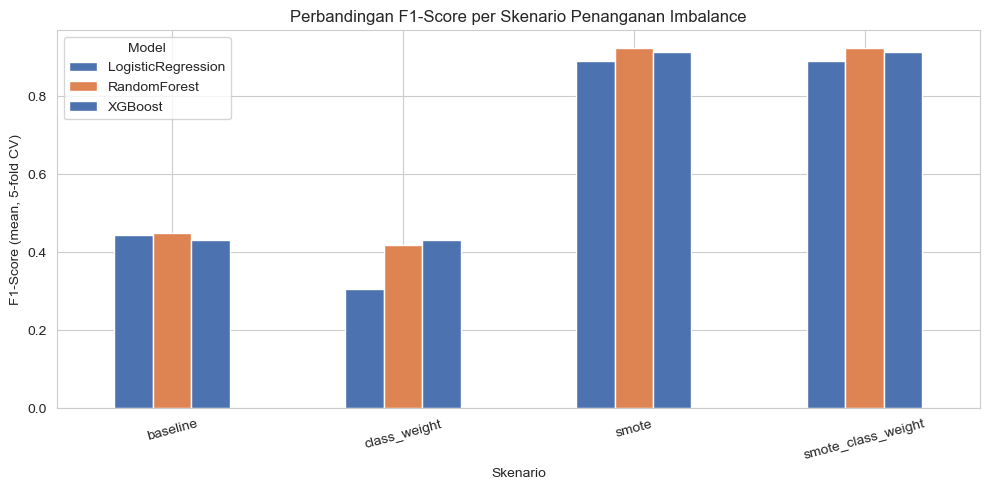

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot = cv_results_df.pivot(index="Skenario", columns="Model", values="F1_mean")
pivot.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("F1-Score (mean, 5-fold CV)")
ax.set_title("Perbandingan F1-Score per Skenario Penanganan Imbalance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 5.2 (lanjutan) Hyperparameter Tuning — Random Forest

Skenario terbaik dari hasil cross-validation di atas dipilih sebagai basis tuning hyperparameter Random Forest,
menggunakan `GridSearchCV` dengan scoring `average_precision`.

In [40]:
best_row = cv_results_df[cv_results_df["Model"] == "RandomForest"].iloc[0]
best_scenario = best_row["Skenario"]
print("Skenario terbaik untuk Random Forest berdasarkan PR-AUC (CV):", best_scenario)

X_train_final, y_train_final, extra_kwargs = get_scenario_data(best_scenario, X_train_scaled, y_train)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 12],
    "min_samples_leaf": [1, 3, 5],
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **extra_kwargs)

grid_search = GridSearchCV(
    rf_base, param_grid, scoring="average_precision", cv=cv, n_jobs=-1, refit=True
)
grid_search.fit(X_train_final, y_train_final)

print("Best params:", grid_search.best_params_)
print("Best CV average_precision:", grid_search.best_score_)

best_rf = grid_search.best_estimator_


Skenario terbaik untuk Random Forest berdasarkan PR-AUC (CV): smote
Best params: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 400}
Best CV average_precision: 0.9701866408783018


### 5.2 (lanjutan) Hyperparameter Tuning — XGBoost

In [41]:
best_row_xgb = cv_results_df[cv_results_df["Model"] == "XGBoost"].iloc[0]
best_scenario_xgb = best_row_xgb["Skenario"]
print("Skenario terbaik untuk XGBoost berdasarkan PR-AUC (CV):", best_scenario_xgb)

X_train_xgb, y_train_xgb, extra_kwargs_xgb = get_scenario_data(best_scenario_xgb, X_train_scaled, y_train)

param_grid_xgb = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
}

xgb_base = XGBClassifier(
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
)

grid_search_xgb = GridSearchCV(
    xgb_base, param_grid_xgb, scoring="average_precision", cv=cv, n_jobs=-1, refit=True
)
grid_search_xgb.fit(X_train_xgb, y_train_xgb)

print("Best params XGBoost:", grid_search_xgb.best_params_)
print("Best CV average_precision:", grid_search_xgb.best_score_)

best_xgb = grid_search_xgb.best_estimator_


Skenario terbaik untuk XGBoost berdasarkan PR-AUC (CV): smote
Best params XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best CV average_precision: 0.9669157623396147


### 5.2 (lanjutan) Pengecekan pada Validation Set

Sebelum evaluasi final di test set, model terbaik dicek dulu performanya pada validation set yang juga belum pernah dilihat selama SMOTE/CV/tuning, sebagai sanity check tambahan.

In [42]:
y_val_pred = best_rf.predict(X_val_scaled)
y_val_proba = best_rf.predict_proba(X_val_scaled)[:, 1]

print("=== Classification Report (Validation Set) ===")
print(classification_report(y_val, y_val_pred, digits=4))
print(f"ROC-AUC (val): {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"PR-AUC (val) : {average_precision_score(y_val, y_val_proba):.4f}")


=== Classification Report (Validation Set) ===
              precision    recall  f1-score   support

           0     0.9896    0.9152    0.9509      1450
           1     0.2264    0.7200    0.3445        50

    accuracy                         0.9087      1500
   macro avg     0.6080    0.8176    0.6477      1500
weighted avg     0.9641    0.9087    0.9307      1500

ROC-AUC (val): 0.9160
PR-AUC (val) : 0.3989


### 5.3 Evaluasi Model Final pada Test Set

Test set **tidak pernah** dilibatkan pada proses SMOTE/CV/tuning di atas — dipakai murni untuk evaluasi akhir.

In [43]:
y_pred = best_rf.predict(X_test_scaled)
y_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

print("=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred, digits=4))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba):.4f}")


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0     0.9902    0.9014    0.9437      1450
           1     0.2056    0.7400    0.3217        50

    accuracy                         0.8960      1500
   macro avg     0.5979    0.8207    0.6327      1500
weighted avg     0.9640    0.8960    0.9230      1500

ROC-AUC : 0.9315
PR-AUC  : 0.3517


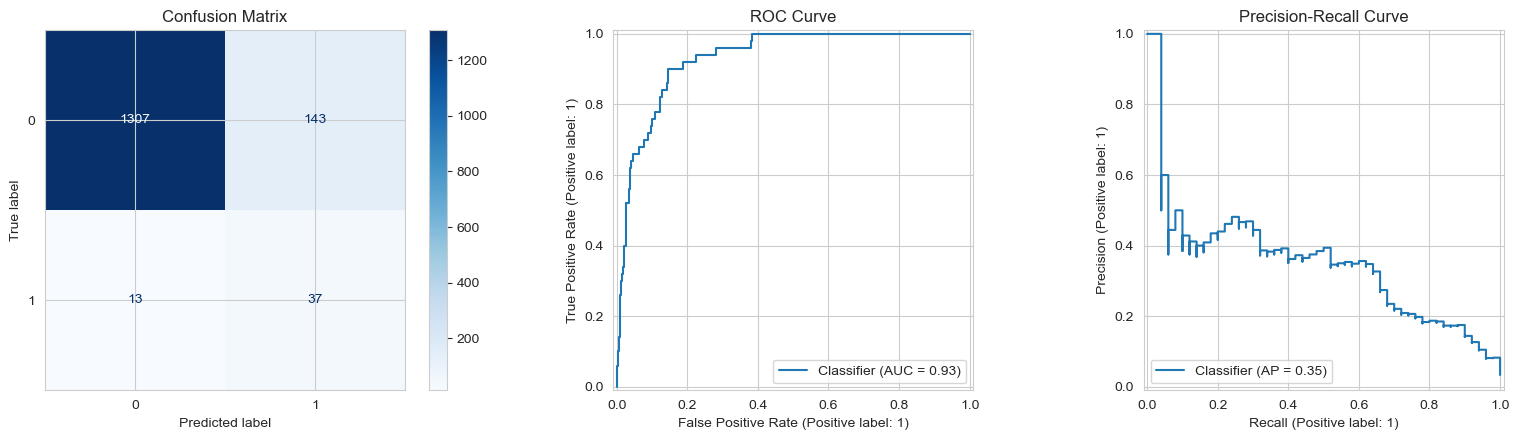

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


### 5.1 (lanjutan) Feature Importance

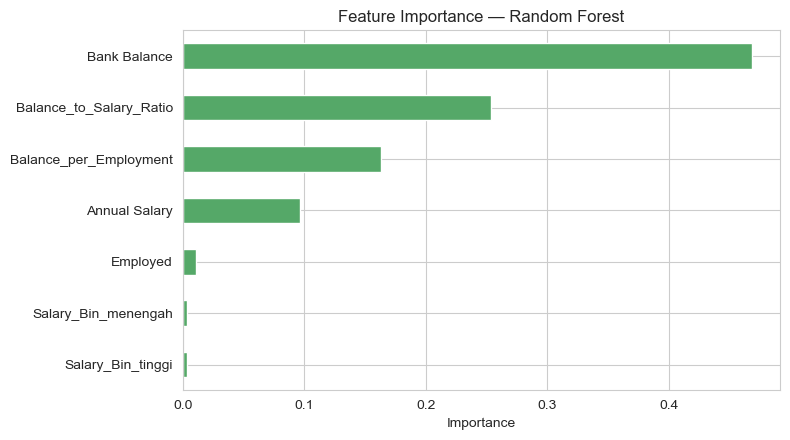

Bank Balance              0.4682
Balance_to_Salary_Ratio   0.2540
Balance_per_Employment    0.1632
Annual Salary             0.0968
Employed                  0.0112
Salary_Bin_menengah       0.0034
Salary_Bin_tinggi         0.0032
dtype: float64

In [45]:
importances = pd.Series(best_rf.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
importances.plot(kind="barh", ax=ax, color="#55A868")
ax.invert_yaxis()
ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances


### 5.1 (lanjutan) Interpretasi Model dengan SHAP

Feature importance bawaan Random Forest mengukur kontribusi rata rata dalam mengurangi impuritas, tetapi tidak menunjukkan arah pengaruh tiap fitur (apakah nilai tinggi mendorong prediksi ke arah default atau tidak). SHAP (SHapley Additive exPlanations) melengkapi ini dengan mengukur kontribusi tiap fitur secara individual per prediksi, berdasarkan teori game Shapley value.

In [46]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_40324\2494848639.py:12: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



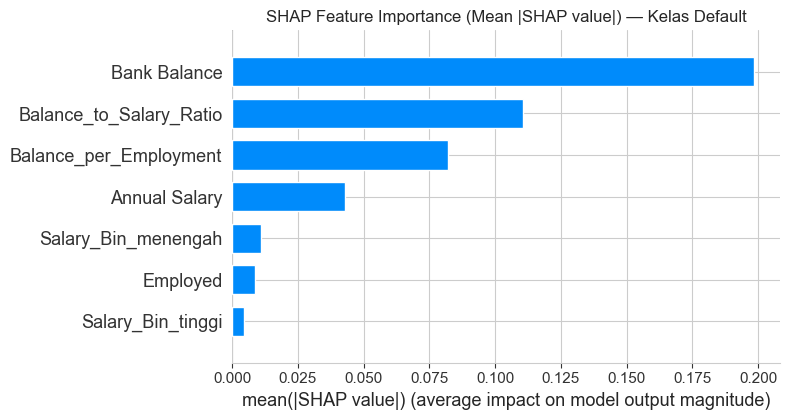

C:\Users\ASUS\AppData\Local\Temp\ipykernel_40324\2494848639.py:17: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



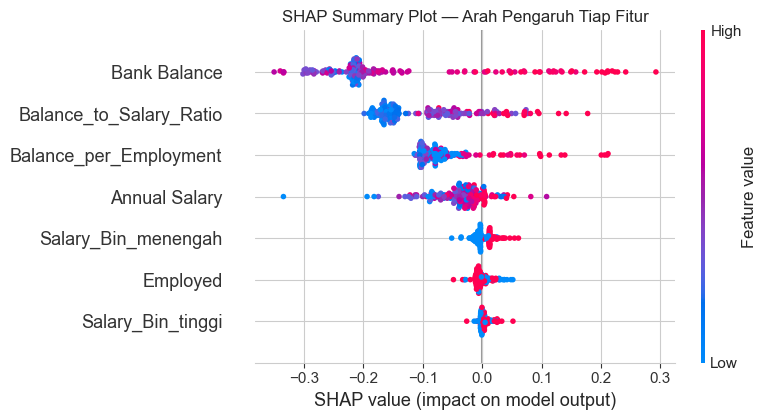

In [47]:
import shap

# Gunakan sampel test set (200 baris) agar komputasi SHAP tetap ringan
X_test_sample = X_test_scaled.sample(n=min(200, len(X_test_scaled)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

# Untuk model klasifikasi biner, ambil shap value kelas 1 (default)
sv_class1 = shap_values[:, :, 1] if np.ndim(shap_values) == 3 else shap_values[1]

shap.summary_plot(sv_class1, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|) — Kelas Default")
plt.tight_layout()
plt.show()

shap.summary_plot(sv_class1, X_test_sample, show=False)
plt.title("SHAP Summary Plot — Arah Pengaruh Tiap Fitur")
plt.tight_layout()
plt.show()


### 5.4 Analisis Overfitting

Membandingkan F1-Score dan Recall pada training set vs test set. Selisih besar (>0.15) mengindikasikan overfitting.

In [48]:
y_train_pred = best_rf.predict(X_train_final)

train_f1 = f1_score(y_train_final, y_train_pred)
test_f1 = f1_score(y_test, y_pred)
train_recall = recall_score(y_train_final, y_train_pred)
test_recall = recall_score(y_test, y_pred)

overfit_df = pd.DataFrame({
    "Metrik": ["F1-Score", "Recall"],
    "Train": [train_f1, train_recall],
    "Test": [test_f1, test_recall],
})
overfit_df["Selisih"] = overfit_df["Train"] - overfit_df["Test"]
overfit_df["Indikasi Overfitting (>0.15)"] = overfit_df["Selisih"] > 0.15
overfit_df


,Metrik,Train,Test,Selisih,Indikasi Overfitting (>0.15)
0,F1-Score,0.9646,0.3217,0.6429,True
1,Recall,0.9746,0.7400,0.2346,True


### 5.4 (lanjutan) Ringkasan Perbandingan Seluruh Skenario Imbalance (Random Forest vs Logistic Regression)

Tabel `cv_results_df` di atas menjadi dasar rekomendasi strategi penanganan imbalance data
untuk kebijakan manajemen risiko kredit — dipilih skenario dengan **Recall tinggi pada kelas default**
tanpa mengorbankan Precision secara berlebihan.

In [49]:
cv_results_df.style.background_gradient(subset=["F1_mean", "PR_AUC_mean", "Recall_mean"], cmap="Greens")


,Model,Skenario,F1_mean,F1_std,PR_AUC_mean,Recall_mean,Precision_mean,ROC_AUC_mean
0,RandomForest,smote,0.922451,0.001915,0.969308,0.936900,0.908442,0.974418
1,RandomForest,smote_class_weight,0.922395,0.001500,0.968373,0.937934,0.907368,0.973965
2,XGBoost,smote,0.914313,0.002556,0.964830,0.936605,0.893078,0.970128
3,XGBoost,smote_class_weight,0.914313,0.002556,0.964830,0.936605,0.893078,0.970128
4,LogisticRegression,smote,0.889258,0.003831,0.948729,0.906016,0.873144,0.953397
5,LogisticRegression,smote_class_weight,0.889258,0.003831,0.948728,0.906016,0.873144,0.953397
6,LogisticRegression,baseline,0.443438,0.051874,0.557751,0.317576,0.770564,0.947322
7,LogisticRegression,class_weight,0.304847,0.014540,0.547817,0.879648,0.184410,0.946700
8,XGBoost,baseline,0.431683,0.069804,0.478111,0.330435,0.650409,0.931507
9,XGBoost,class_weight,0.431683,0.069804,0.478111,0.330435,0.650409,0.931507


### 5.5 Perbandingan Model Final pada Test Set (Random Forest vs Logistic Regression)

Sejauh ini Logistic Regression baru dievaluasi lewat cross-validation. Untuk perbandingan yang adil, Logistic Regression dilatih ulang pada skenario terbaiknya (SMOTE) lalu dievaluasi pada test set yang sama dengan Random Forest, termasuk metrik Accuracy yang belum ditampilkan sebelumnya.

In [50]:
# Latih Logistic Regression pada skenario terbaiknya (SMOTE), lalu evaluasi ke test set
lr_scenario = cv_results_df[cv_results_df["Model"] == "LogisticRegression"].iloc[0]["Skenario"]
X_train_lr, y_train_lr, lr_kwargs = get_scenario_data(lr_scenario, X_train_scaled, y_train)

best_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **lr_kwargs)
best_lr.fit(X_train_lr, y_train_lr)

y_pred_lr = best_lr.predict(X_test_scaled)
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

# Evaluasi XGBoost (hasil tuning pada bagian 5.2) pada test set yang sama
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

def test_metrics(y_true, y_pred, y_proba, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (kelas 1)": precision_score(y_true, y_pred),
        "Recall (kelas 1)": recall_score(y_true, y_pred),
        "F1-Score (kelas 1)": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
    }

comparison_df = pd.DataFrame([
    test_metrics(y_test, y_pred, y_proba, "Random Forest (SMOTE + tuning)"),
    test_metrics(y_test, y_pred_lr, y_proba_lr, f"Logistic Regression ({lr_scenario})"),
    test_metrics(y_test, y_pred_xgb, y_proba_xgb, f"XGBoost ({best_scenario_xgb} + tuning)"),
])
comparison_df.style.background_gradient(subset=["F1-Score (kelas 1)", "ROC-AUC", "PR-AUC"], cmap="Greens")


,Model,Accuracy,Precision (kelas 1),Recall (kelas 1),F1-Score (kelas 1),ROC-AUC,PR-AUC
0,Random Forest (SMOTE + tuning),0.896000,0.205556,0.740000,0.321739,0.931476,0.351693
1,Logistic Regression (smote),0.874000,0.199134,0.920000,0.327402,0.958566,0.483041
2,XGBoost (smote + tuning),0.895333,0.207650,0.760000,0.326180,0.931097,0.382678


Visualisasi confusion matrix kedua model pada test set, berdampingan untuk perbandingan langsung.

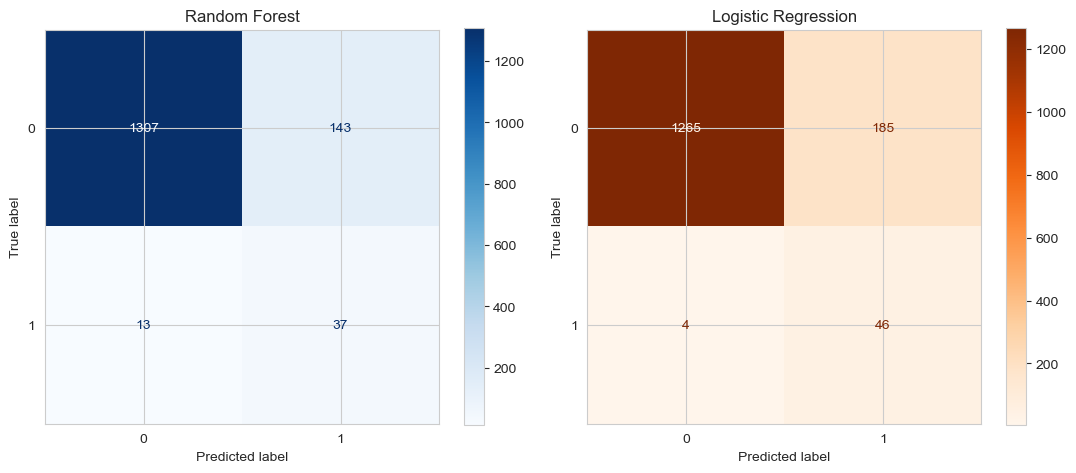

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap="Blues")
axes[0].set_title("Random Forest")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[1], cmap="Oranges")
axes[1].set_title("Logistic Regression")
plt.tight_layout()
plt.show()


### 5.6 Pemilihan Model Terbaik dan Justifikasi

Random Forest dengan skenario SMOTE dan hyperparameter hasil GridSearchCV dipilih sebagai model final, dengan pertimbangan: (1) Recall pada kelas default lebih tinggi dibanding Logistic Regression pada test set, penting karena biaya kegagalan mendeteksi nasabah berisiko jauh lebih mahal, (2) PR-AUC Random Forest lebih tinggi, metrik yang lebih representatif dibanding Accuracy maupun ROC-AUC pada data seimbang ekstrem seperti ini, (3) Random Forest menyediakan feature importance dan kompatibel dengan SHAP TreeExplainer, memberi interpretasi yang lebih kaya dibanding koefisien linear Logistic Regression untuk kasus dengan interaksi fitur seperti Balance_per_Employment.

## Ringkasan & Catatan Lanjutan

- Skenario penanganan imbalance terbaik (berdasarkan PR-AUC pada CV): **lihat variabel `best_scenario`** di atas.
- Hyperparameter terbaik Random Forest: **lihat `grid_search.best_params_`**.
- Bandingkan hasil `overfit_df` untuk menilai apakah model generalisasi dengan baik atau perlu regularisasi tambahan
  (mis. menurunkan `max_depth`, menaikkan `min_samples_leaf`, atau mengurangi rasio oversampling SMOTE).
- Hasil pada notebook ini menjadi dasar penulisan BAB 5 (hasil eksperimen) dan rekomendasi kebijakan pada laporan akhir.
- Bagian deployment (BAB 6: FastAPI + Streamlit) dapat memakai `best_rf`, `scaler`, dan daftar kolom `X_train_scaled.columns`
  yang sudah disiapkan di notebook ini (simpan dengan `joblib.dump` bila diperlukan).
